# SEAS5
<!-- markdownlint-disable MD013 -->
Loads SEAS5 and ERA5 forecasts for a `pcode` to plot current value compared to historical values.

In [30]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import calendar
from typing import List

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import xarray as xr
import numpy as np
import seaborn as sns
import ocha_stratus as stratus

from src.datasources import seas5, era5
from src.utils import blob_utils, rp_calc
from src.utils.timeseries import detrend_column

In [51]:
pcode = "SS"

In [52]:
query = f"SELECT * FROM public.polygon WHERE pcode = '{pcode}'"
df_adm = pd.read_sql(query, stratus.get_engine(stage="prod"))
adm_name = df_adm.iloc[0]["name"]

In [53]:
adm_name

'South Sudan'

In [54]:
df_era5 = era5.load_era5(pcode=pcode)

In [55]:
df_era5

,iso3,pcode,valid_date,adm_level,mean,median,min,max,count,sum,std
0,SSD,SS,1981-01-01,0,0.054603,0.009537,0.000000,1.792908,21046,1149.1661,0.145196
1,SSD,SS,1981-02-01,0,0.212210,0.089645,0.000000,1.966476,21046,4466.1714,0.286513
2,SSD,SS,1981-03-01,0,2.475634,2.099991,0.045776,13.021469,21046,52102.1950,1.778386
3,SSD,SS,1981-04-01,0,1.769028,1.277924,0.219345,12.819290,21046,37230.9570,1.326667
4,SSD,SS,1981-05-01,0,4.789002,4.524231,1.287460,16.954422,21046,100789.3300,1.447784
...,...,...,...,...,...,...,...,...,...,...,...
526,SSD,SS,2013-11-01,0,1.340969,0.728607,0.000000,11.085510,21046,28222.0250,1.473728
527,SSD,SS,2013-12-01,0,0.031203,0.001907,0.000000,1.106262,21046,656.6944,0.089022
528,SSD,SS,2022-12-01,0,0.090749,0.001907,0.000000,1.749039,21046,1909.8988,0.192860
529,SSD,SS,2024-10-01,0,2.905493,2.244949,0.255585,12.170792,21046,61149.0100,1.871944


In [56]:
df_seas5 = seas5.load_seas5(pcode=pcode)

In [57]:
df_seas5

,iso3,pcode,valid_date,issued_date,leadtime,adm_level,mean,median,min,max,count,sum,std
0,SSD,SS,2018-01-01,2018-01-01,0,0,0.005379,0.000320,-4.061350e-20,0.061619,21029,113.11096,0.010666
1,SSD,SS,2018-02-01,2018-02-01,0,0,0.249703,0.171878,6.163164e-04,1.580420,21029,5251.01030,0.267869
2,SSD,SS,2018-02-01,2018-01-01,1,0,0.088453,0.050126,2.139258e-03,0.661548,21029,1860.06910,0.098685
3,SSD,SS,2018-03-01,2018-03-01,0,0,1.188260,0.698780,5.263342e-03,6.106771,21029,24987.91400,1.171727
4,SSD,SS,2018-03-01,2018-02-01,1,0,0.721690,0.475818,2.160545e-02,3.946260,21029,15176.41800,0.656137
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3726,SSD,SS,2015-09-01,2015-09-01,0,0,5.917744,6.414143,3.713015e-01,9.457275,21029,124444.23000,1.580023
3727,SSD,SS,2015-09-01,2015-08-01,1,0,5.175541,5.588921,3.177259e-01,8.490030,21029,108836.45000,1.562611
3728,SSD,SS,2015-09-01,2015-07-01,2,0,4.759479,4.995679,2.608176e-01,8.275936,21029,100087.08600,1.556630
3729,SSD,SS,2015-09-01,2015-06-01,3,0,4.660870,4.891117,2.359918e-01,8.656534,21029,98013.43000,1.557820


<Axes: xlabel='valid_date'>

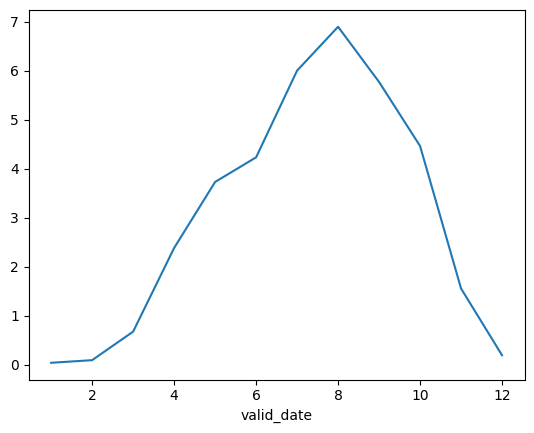

In [58]:
df_seas5.groupby(df_seas5["valid_date"].dt.month)["mean"].mean().plot()

In [59]:
df_seas5.groupby(df_seas5["valid_date"].dt.month)["mean"].mean()

valid_date
1     0.039577
2     0.093163
3     0.675960
4     2.383946
5     3.732836
6     4.235238
7     6.007236
8     6.901894
9     5.774293
10    4.467003
11    1.556191
12    0.192799
Name: mean, dtype: float64

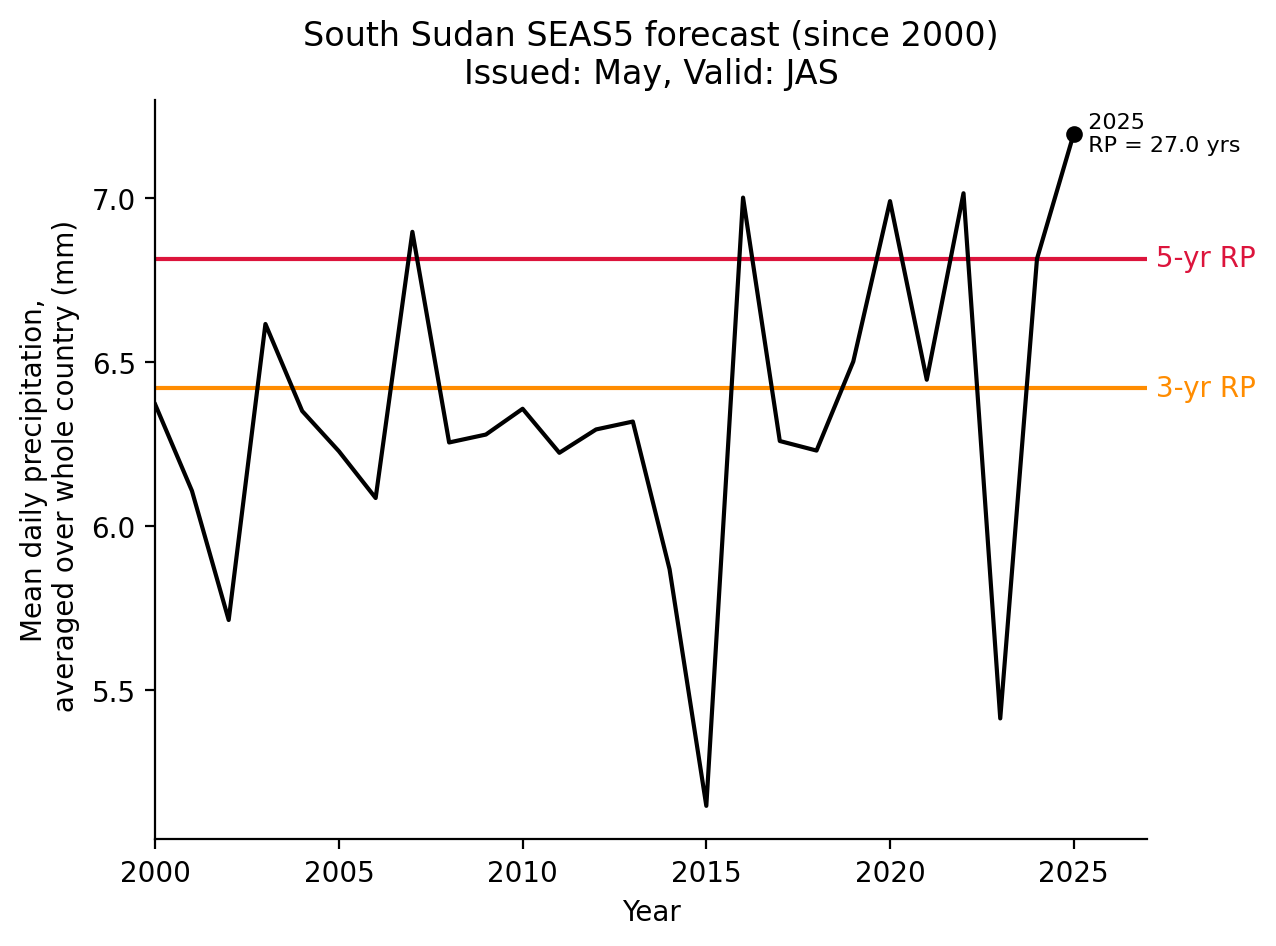

In [60]:
issued_month = 5
# valid_months = [5, 6, 7, 8, 9, 10]
# valid_months = [4, 5, 7, 8, 9, 10]
valid_months = [7, 8, 9]
# valid_months = [4]
min_year = 2000

valid_mo_str = "".join([calendar.month_abbr[x][0] for x in valid_months])

df_plot = (
    df_seas5[
        (df_seas5["valid_date"].dt.month.isin(valid_months))
        & (df_seas5["issued_date"].dt.month == issued_month)
        & (df_seas5["valid_date"].dt.year >= min_year)
    ]
    .groupby("issued_date")["mean"]
    .mean()
    .reset_index()
)
df_plot["year"] = df_plot["issued_date"].dt.year

df_plot = rp_calc.calculate_one_group_rp(df_plot, ascending=False)

issued_month_str = calendar.month_abbr[issued_month]

valid_months_str = "".join([calendar.month_abbr[x][0] for x in valid_months])

thresh = df_plot["mean"].quantile(2 / 3)

fig, ax = plt.subplots(dpi=200)

current_row = df_plot[df_plot["issued_date"].dt.year == 2025].iloc[0]

ax.annotate(
    f"  2025\n  RP = {current_row['mean_rp']:.1f} yrs",
    (2025, current_row["mean"]),
    ha="left",
    va="center",
    fontsize=8,
)

for rp, color in zip([3, 5], ["darkorange", "crimson"]):
    thresh = df_plot["mean"].quantile((rp - 1) / rp)
    ax.axhline(thresh, color=color)
    ax.annotate(
        f" {rp}-yr RP", (2027, thresh), va="center", ha="left", color=color
    )

df_plot.plot(x="year", y="mean", ax=ax, legend=False, color="k")

ax.plot(
    [2025],
    [current_row["mean"]],
    marker=".",
    color="k",
    markersize=10,
)

ax.set_title(
    f"{adm_name} SEAS5 forecast (since {min_year})\n"
    f"Issued: {issued_month_str}, Valid: {valid_mo_str}"
)
ax.set_xlabel("Year")
ax.set_ylabel("Mean daily precipitation,\n averaged over whole country (mm)")

ax.set_xlim(left=min_year, right=2027)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

y.mean()=np.float64(6.3454862512820505)
a=np.float64(0.01617899758404612), b=np.float64(-26.214746386610766)


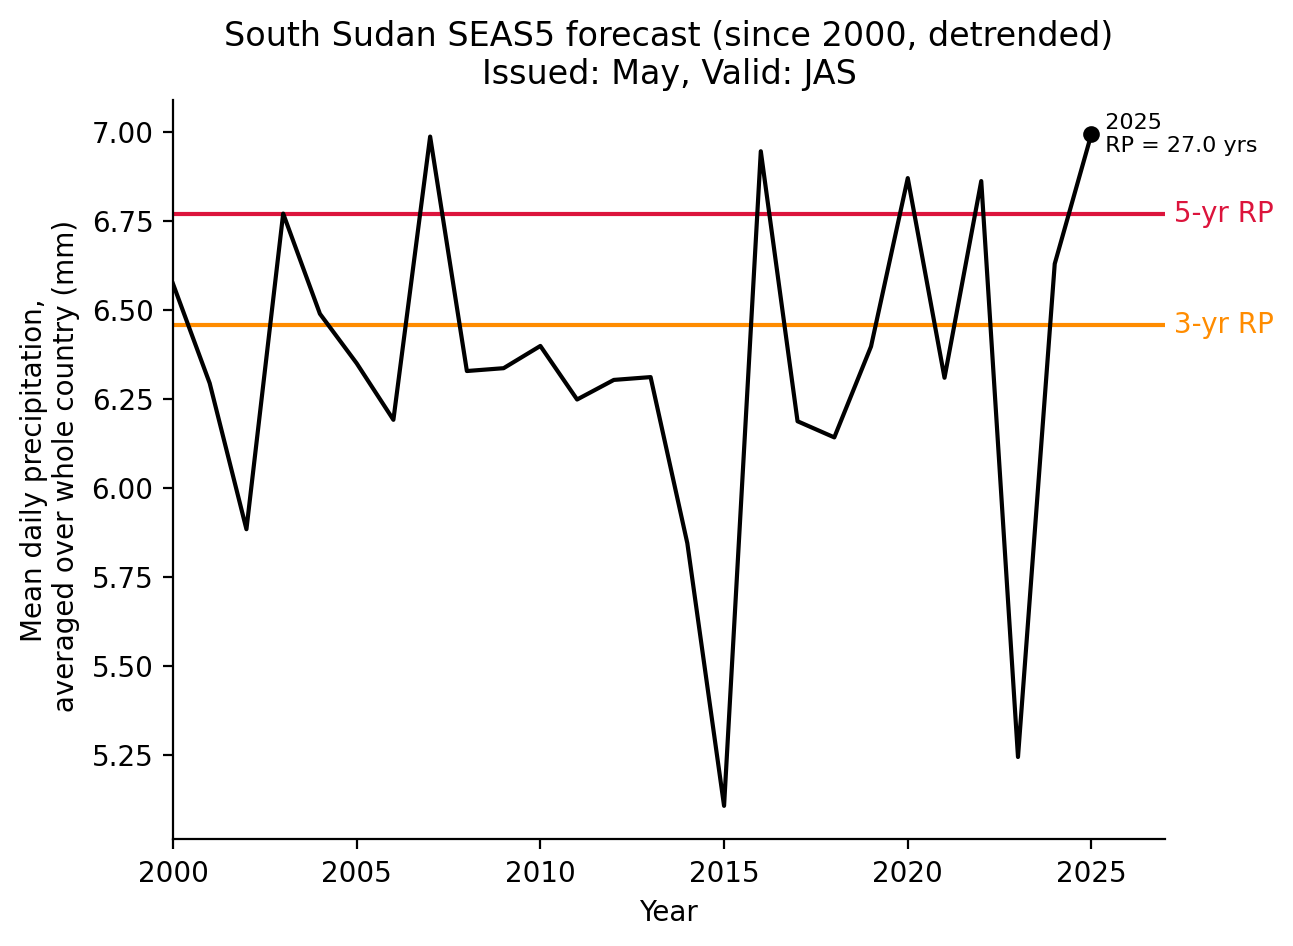

In [61]:
issued_month = 5
# valid_months = [5, 6, 7, 8, 9, 10]
# valid_months = [4, 5, 7, 8, 9, 10]
valid_months = [7, 8, 9]
# valid_months = [4]
min_year = 2000

valid_mo_str = "".join([calendar.month_abbr[x][0] for x in valid_months])

df_plot = (
    df_seas5[
        (df_seas5["valid_date"].dt.month.isin(valid_months))
        & (df_seas5["issued_date"].dt.month == issued_month)
        & (df_seas5["valid_date"].dt.year >= min_year)
    ]
    .groupby("issued_date")["mean"]
    .mean()
    .reset_index()
)
df_plot["year"] = df_plot["issued_date"].dt.year
df_plot = detrend_column(df_plot, "mean", index_col="year")

df_plot = rp_calc.calculate_one_group_rp(
    df_plot, ascending=False, col_name="mean_detrended"
)

issued_month_str = calendar.month_abbr[issued_month]

valid_months_str = "".join([calendar.month_abbr[x][0] for x in valid_months])

thresh = df_plot["mean"].quantile(2 / 3)

fig, ax = plt.subplots(dpi=200)

current_row = df_plot[df_plot["issued_date"].dt.year == 2025].iloc[0]

ax.annotate(
    f"  2025\n  RP = {current_row['mean_detrended_rp']:.1f} yrs",
    (2025, current_row["mean_detrended"]),
    ha="left",
    va="center",
    fontsize=8,
)

for rp, color in zip([3, 5], ["darkorange", "crimson"]):
    thresh = df_plot["mean_detrended"].quantile((rp - 1) / rp)
    ax.axhline(thresh, color=color)
    ax.annotate(
        f" {rp}-yr RP", (2027, thresh), va="center", ha="left", color=color
    )

df_plot.plot(x="year", y="mean_detrended", ax=ax, legend=False, color="k")

ax.plot(
    [2025],
    [current_row["mean_detrended"]],
    marker=".",
    color="k",
    markersize=10,
)

ax.set_title(
    f"{adm_name} SEAS5 forecast (since {min_year}, detrended)\n"
    f"Issued: {issued_month_str}, Valid: {valid_mo_str}"
)
ax.set_xlabel("Year")
ax.set_ylabel("Mean daily precipitation,\n averaged over whole country (mm)")

ax.set_xlim(left=min_year, right=2027)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

In [62]:
df_plot

,issued_date,mean,year,mean_detrended,mean_detrended_rank,mean_detrended_rp
0,2000-05-01,6.370819,2000,6.573056,8.0,3.375000
1,2001-05-01,6.107337,2001,6.293395,18.0,1.500000
2,2002-05-01,5.713399,2002,5.883278,23.0,1.173913
3,2003-05-01,6.616325,2003,6.770026,6.0,4.500000
4,2004-05-01,6.350943,2004,6.488465,9.0,3.000000
5,2005-05-01,6.228102,2005,6.349445,12.0,2.250000
6,2006-05-01,6.085460,2006,6.190624,20.0,1.350000
7,2007-05-01,6.897371,2007,6.986355,2.0,13.500000
8,2008-05-01,6.254890,2008,6.327695,14.0,1.928571
9,2009-05-01,6.279039,2009,6.335665,13.0,2.076923


In [63]:
df_compare = df_seas5.merge(
    df_era5,
    on=["valid_date", "pcode", "adm_level", "iso3"],
    suffixes=["_s", "_e"],
    how="left",
)

In [64]:
df_season = (
    df_compare[
        (df_compare["valid_date"].dt.month.isin(valid_months))
        & (df_compare["issued_date"].dt.month == issued_month)
        & (df_compare["valid_date"].dt.year >= min_year)
    ]
    .groupby("issued_date")[["mean_s", "mean_e"]]
    .mean()
    .reset_index()
)
df_season["year"] = df_season["issued_date"].dt.year

corr = df_season.corr().loc["mean_s", "mean_e"]

In [65]:
corr

np.float64(0.6039204889602733)

In [66]:
df_season

,issued_date,mean_s,mean_e,year
0,2000-05-01,6.370819,5.684529,2000
1,2001-05-01,6.107337,5.969749,2001
2,2002-05-01,5.713399,4.051516,2002
3,2003-05-01,6.616325,5.655184,2003
4,2004-05-01,6.350943,4.679939,2004
5,2005-05-01,6.228102,5.119211,2005
6,2006-05-01,6.085460,5.186454,2006
7,2007-05-01,6.897371,5.577635,2007
8,2008-05-01,6.254890,5.385251,2008
9,2009-05-01,6.279039,4.490620,2009


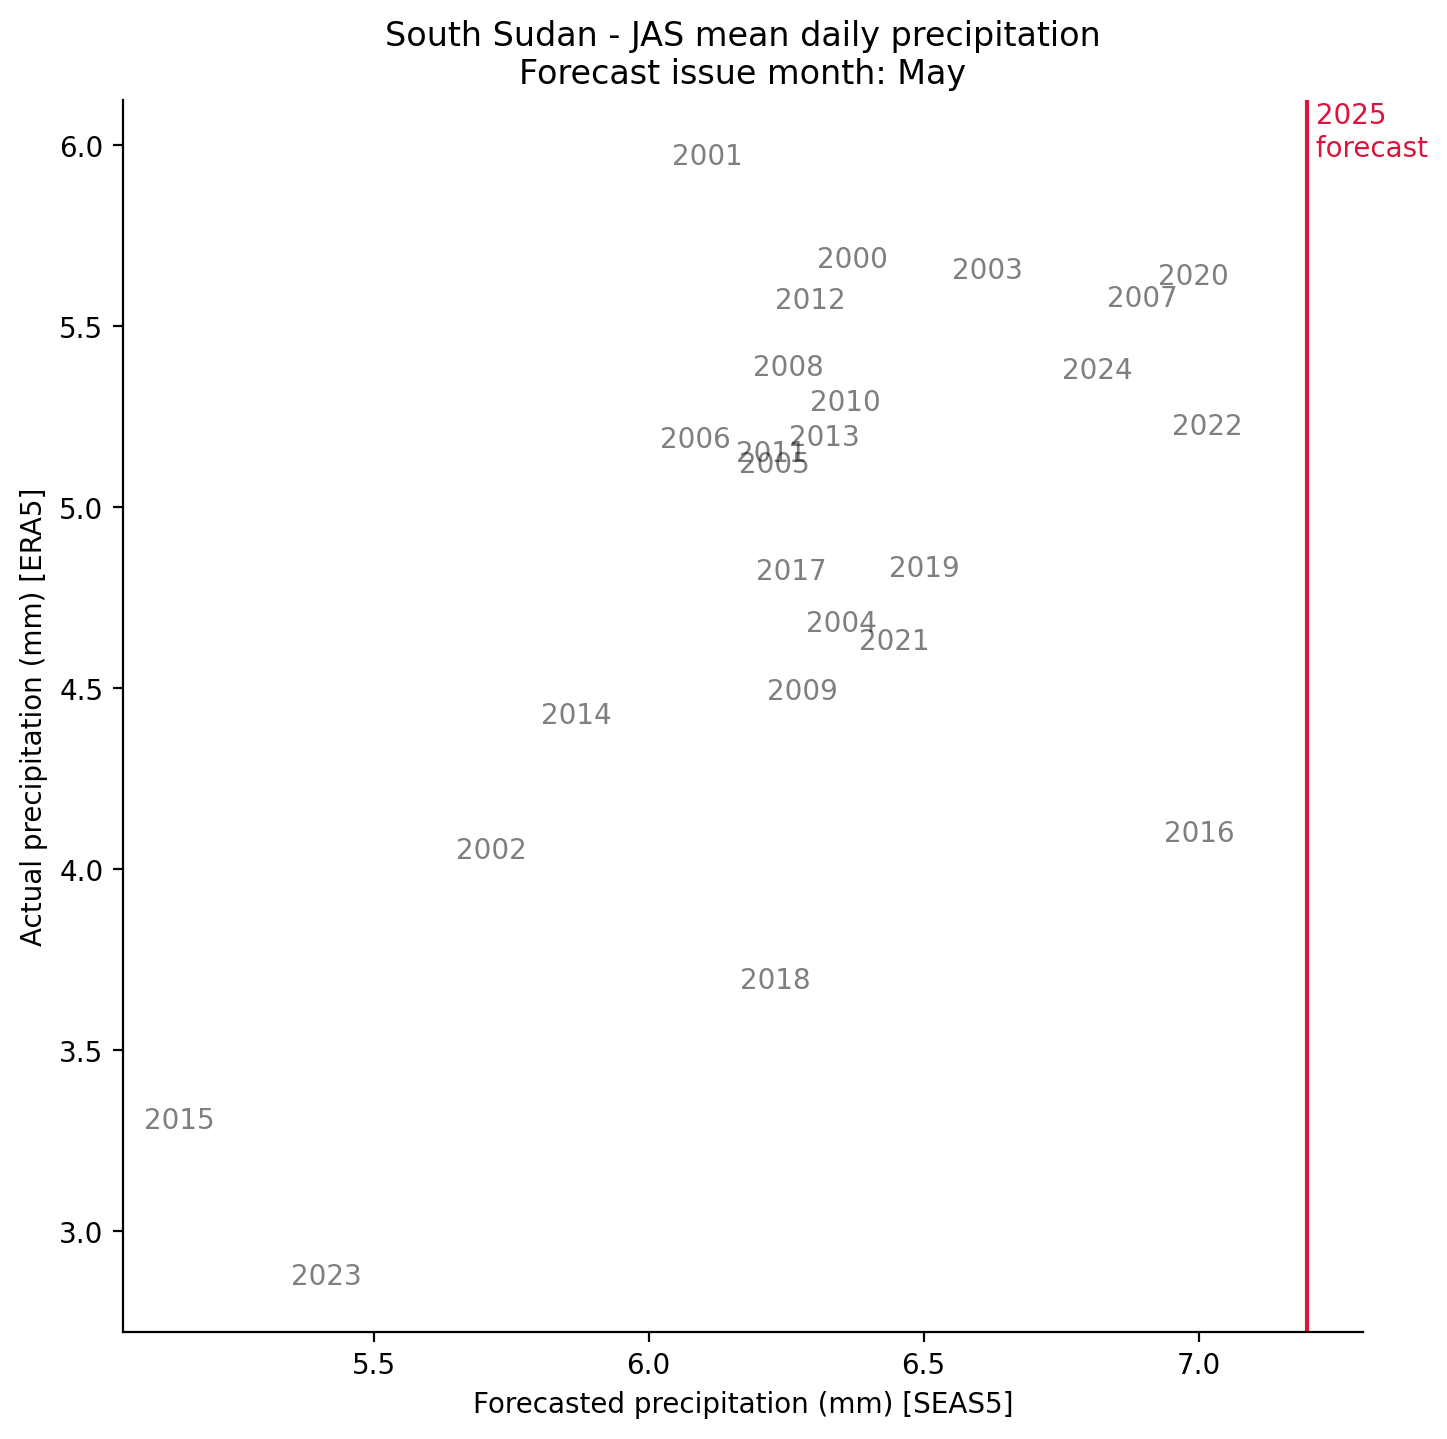

In [67]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=200)

for year, row in df_season.set_index("year").iterrows():
    ax.annotate(
        year,
        (row["mean_s"], row["mean_e"]),
        ha="center",
        va="center",
        fontsize=10,
        alpha=0.5,
    )

df_season.plot(x="mean_s", y="mean_e", linewidth=0, legend=False, ax=ax)

current_row = df_season.set_index("year").loc[2025]
current_color = "crimson"

ax.axvline(current_row["mean_s"], color=current_color)
ax.annotate(
    f" {current_row['issued_date'].year}\n forecast",
    (current_row["mean_s"], df_season["mean_e"].max()),
    color="crimson",
)

ax.set_xlabel("Forecasted precipitation (mm) [SEAS5]")
ax.set_ylabel("Actual precipitation (mm) [ERA5]")

ax.set_title(
    f"{adm_name} - {valid_mo_str} mean daily precipitation\n"
    f"Forecast issue month: {calendar.month_abbr[issued_month]}"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

## Full correlation analysis

Looking at correlation per leadtime per issued month.

In [19]:
df_compare = df_seas5.merge(
    df_era5,
    on=["valid_date", "pcode", "adm_level", "iso3"],
    suffixes=["_s", "_e"],
    how="left",
)

In [20]:
df_compare

,iso3,pcode,valid_date,issued_date,leadtime,adm_level,mean_s,median_s,min_s,max_s,count_s,sum_s,std_s,mean_e,median_e,min_e,max_e,count_e,sum_e,std_e
0,SSD,SS,2021-01-01,2021-01-01,0,0,0.050585,0.002502,-2.224914e-20,0.483697,21029,1063.7543,0.083480,0.028973,0.000000,0.000000,0.877380,21046.0,609.7736,0.069111
1,SSD,SS,2021-02-01,2021-02-01,0,0,0.064781,0.023790,2.465266e-05,0.579399,21029,1362.2764,0.089170,0.021918,0.000000,0.000000,0.745773,21046.0,461.2932,0.069840
2,SSD,SS,2021-02-01,2021-01-01,1,0,0.056113,0.013601,6.697214e-05,0.616433,21029,1180.0101,0.080139,0.021918,0.000000,0.000000,0.745773,21046.0,461.2932,0.069840
3,SSD,SS,2021-03-01,2021-03-01,0,0,1.042880,0.813784,2.323513e-02,4.447561,21029,21930.7230,0.827078,0.481093,0.316620,0.000000,2.713203,21046.0,10125.0890,0.474359
4,SSD,SS,2021-03-01,2021-02-01,1,0,0.760125,0.571622,1.203125e-02,3.798741,21029,15984.6710,0.675298,0.481093,0.316620,0.000000,2.713203,21046.0,10125.0890,0.474359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3719,SSD,SS,2015-09-01,2015-09-01,0,0,5.917744,6.414143,3.713015e-01,9.457275,21029,124444.2300,1.580023,2.752048,2.742767,0.022888,7.381439,21046.0,57919.6000,1.162076
3720,SSD,SS,2015-09-01,2015-08-01,1,0,5.175541,5.588921,3.177259e-01,8.490030,21029,108836.4500,1.562611,2.752048,2.742767,0.022888,7.381439,21046.0,57919.6000,1.162076
3721,SSD,SS,2015-09-01,2015-07-01,2,0,4.759479,4.995679,2.608176e-01,8.275936,21029,100087.0860,1.556630,2.752048,2.742767,0.022888,7.381439,21046.0,57919.6000,1.162076
3722,SSD,SS,2015-09-01,2015-06-01,3,0,4.660870,4.891117,2.359918e-01,8.656534,21029,98013.4300,1.557820,2.752048,2.742767,0.022888,7.381439,21046.0,57919.6000,1.162076


In [21]:
11 % 12 + 1

12

In [22]:
dicts = []
for i_mo in range(1, 13):
    for v_mo in range(i_mo, i_mo + 7):
        v_mo = (v_mo - 1) % 12 + 1
        valid_months = [v_mo]
        min_year = 2000

        df_season = (
            df_compare[
                (df_compare["valid_date"].dt.month.isin(valid_months))
                & (df_compare["issued_date"].dt.month == i_mo)
                & (df_compare["valid_date"].dt.year >= min_year)
            ]
            .groupby("issued_date")[["mean_s", "mean_e"]]
            .mean()
            .reset_index()
        )
        df_season["year"] = df_season["issued_date"].dt.year

        corr = df_season.corr().loc["mean_s", "mean_e"]
        dicts.append({"i_mo": i_mo, "v_mo": v_mo, "corr": corr})

In [23]:
df_corr = pd.DataFrame(dicts)
df_corr["lt"] = (df_corr["v_mo"] - df_corr["i_mo"]) % 12

<Axes: xlabel='lt'>

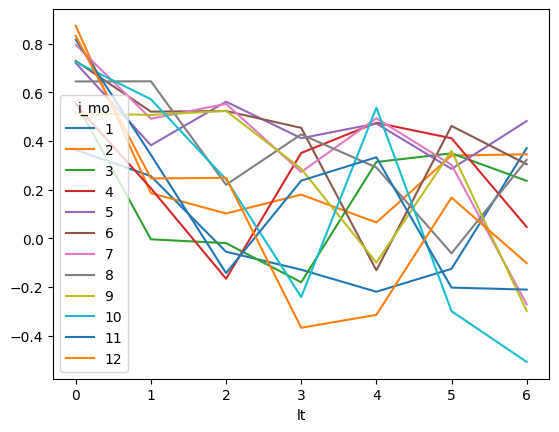

In [24]:
df_corr.pivot(index="lt", columns="i_mo", values="corr").plot()

In [25]:
df_corr

,i_mo,v_mo,corr,lt
0,1,1,0.363513,0
1,1,2,0.255419,1
2,1,3,-0.054887,2
3,1,4,-0.128609,3
4,1,5,-0.219133,4
...,...,...,...,...
79,12,2,0.248431,2
80,12,3,-0.366956,3
81,12,4,-0.314087,4
82,12,5,0.167535,5


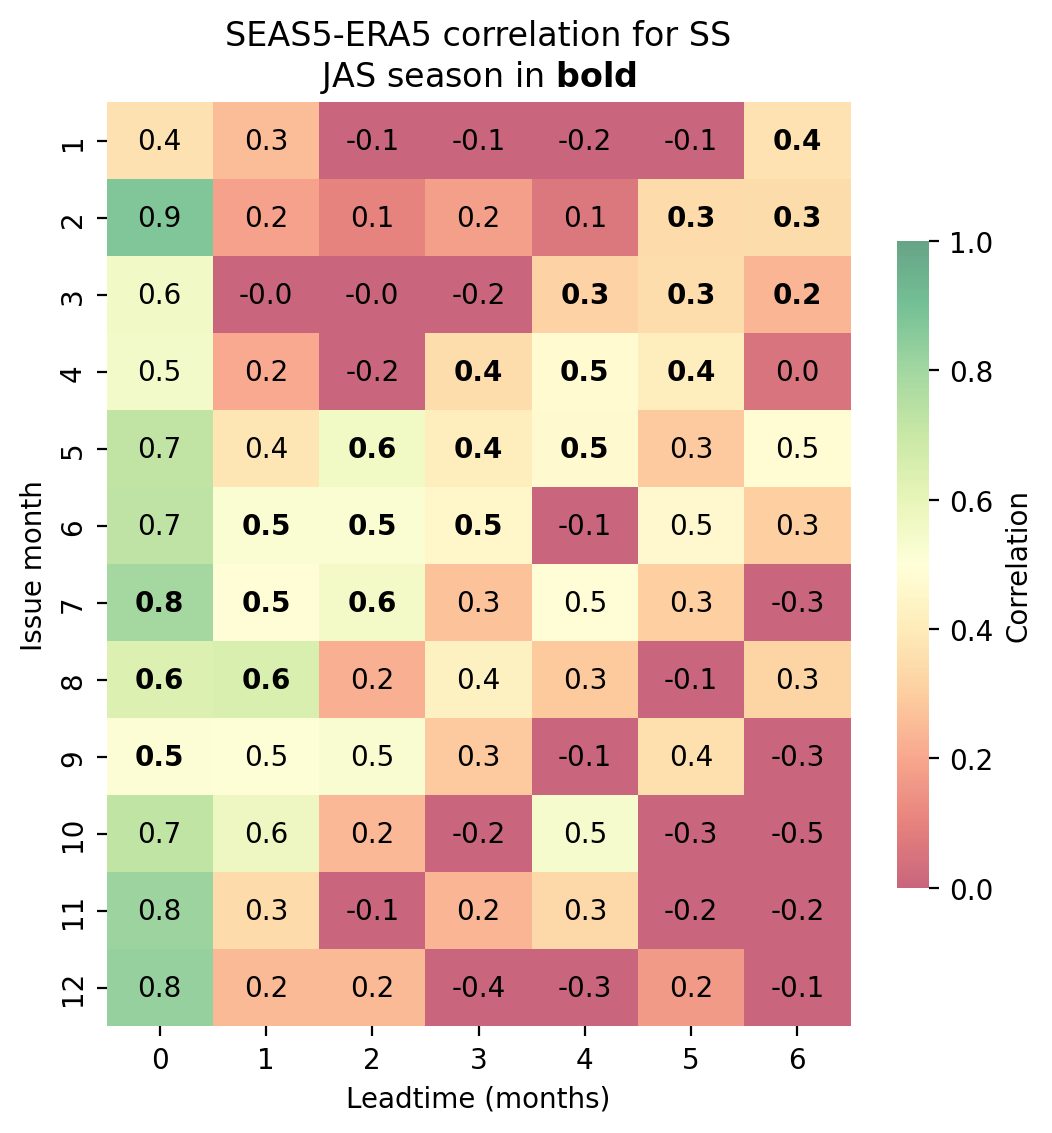

In [26]:
season_months = [7, 8, 9]

season_months_str = "".join([calendar.month_abbr[x][0] for x in season_months])

df_corr_pivot = df_corr.pivot(columns="lt", index="i_mo", values="corr")

df_condition = df_corr_pivot.astype(bool)

for lt in df_condition:
    df_condition[lt] = ((df_condition.index + lt - 1) % 12 + 1).isin(
        season_months
    )
condition = df_condition.to_numpy()

fig, ax = plt.subplots(dpi=200, figsize=(6, 6))

sns.heatmap(
    df_corr_pivot,
    annot=True,
    cmap="RdYlGn",
    fmt=".1f",
    cbar_kws={"label": "Correlation", "shrink": 0.7},
    annot_kws={"color": "black"},
    ax=ax,
    vmax=1,
    vmin=0,
    alpha=0.6,
)

for y_idx in range(df_corr_pivot.shape[0]):  # Iterate over rows (lt)
    for x_idx in range(df_corr_pivot.shape[1]):  # Iterate over columns (i_mo)
        if condition[y_idx, x_idx]:
            # Get the annotation text and set it to bold
            text = ax.texts[y_idx * df_corr_pivot.shape[1] + x_idx]
            text.set_fontweight("bold")

# contour = ax.contour(condition, levels=[0.5], colors="black", linewidths=2)
plt.title(
    f"SEAS5-ERA5 correlation for {pcode}\n"
    f"{season_months_str} season in "
    r"$\bf{bold}$"
)
plt.xlabel("Leadtime (months)")
plt.ylabel("Issue month")
plt.show()

## Nicaragua / other countries

Can ignore below - just sandbox for checking other countries or admins.

In [75]:
ADM1_AOI_PCODES = ["NI25", "NI20", "NI05", "NI40"]

In [78]:
df_seas5 = seas5.load_seas5_multiple_pcodes(ADM1_AOI_PCODES)

In [40]:
df_seas5 = seas5.load_seas5("AO")

In [79]:
df_seas5

,iso3,pcode,valid_date,issued_date,leadtime,adm_level,mean,median,min,max,count,sum,std
0,NIC,NI20,1988-01-01,1988-01-01,0,1,0.705103,0.792819,0.048556,2.616914,58,40.895973,0.727776
1,NIC,NI20,1988-12-01,1988-09-01,3,1,0.666721,0.727299,0.177639,2.149339,58,38.669846,0.560768
2,NIC,NI25,1988-12-01,1988-09-01,3,1,0.277903,0.254484,0.177639,0.883856,75,20.842710,0.148963
3,NIC,NI05,1988-12-01,1988-09-01,3,1,1.871512,2.149339,0.214754,3.531851,119,222.709990,1.036612
4,NIC,NI40,1988-12-01,1988-09-01,3,1,1.845209,1.738005,0.191218,3.592376,230,424.398130,1.213213
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14891,NIC,NI40,2022-05-01,2021-11-01,6,1,3.598183,3.713157,2.005097,4.854908,230,827.582200,0.874179
14892,NIC,NI20,2022-06-01,2021-12-01,6,1,5.569483,4.993486,4.987878,7.502745,58,323.030030,0.835547
14893,NIC,NI25,2022-06-01,2021-12-01,6,1,5.312140,4.999094,4.987878,7.502745,75,398.410520,0.694124
14894,NIC,NI05,2022-06-01,2021-12-01,6,1,6.027585,5.843141,4.987878,8.325822,119,717.282650,0.919044


In [42]:
issued_month = 4
# valid_months = [5, 6, 7, 8]
# valid_months = [7, 8, 9]
valid_months = [4]

In [43]:
df_seas5[
    (df_seas5["valid_date"].dt.month.isin(valid_months))
    & (df_seas5["issued_date"].dt.month == issued_month)
    # & (df_seas5["valid_date"].dt.year >= 1998)
]

,iso3,pcode,valid_date,issued_date,leadtime,adm_level,mean,median,min,max,count,sum,std
6,AGO,AO,1990-04-01,1990-04-01,0,0,3.877745,3.781538,0.403991,8.524320,41530,161042.730,1.618219
16,AGO,AO,1984-04-01,1984-04-01,0,0,3.998295,3.178066,0.588963,14.090221,41530,166049.170,2.943495
52,AGO,AO,1993-04-01,1993-04-01,0,0,3.723203,3.138587,0.067441,11.697659,41530,154624.610,2.125447
70,AGO,AO,1987-04-01,1987-04-01,0,0,3.427874,2.944965,0.118989,9.899439,41530,142359.600,2.314809
97,AGO,AO,1981-04-01,1981-04-01,0,0,2.032318,1.023757,0.034072,9.903110,41530,84402.170,2.126456
220,AGO,AO,1988-04-01,1988-04-01,0,0,4.144969,3.446446,0.127112,12.315464,41530,172140.560,2.411649
239,AGO,AO,1991-04-01,1991-04-01,0,0,3.839571,3.040468,0.077222,13.384733,41530,159457.390,3.093410
251,AGO,AO,1994-04-01,1994-04-01,0,0,3.276430,2.324545,0.079259,12.349385,41530,136070.120,2.862293
562,AGO,AO,1986-04-01,1986-04-01,0,0,3.949583,3.087566,0.156431,13.814978,41530,164026.190,3.313892
642,AGO,AO,2001-04-01,2001-04-01,0,0,4.529505,4.134483,0.986416,12.681107,41530,188110.330,2.297232


In [44]:
df_season = (
    df_seas5[
        (df_seas5["valid_date"].dt.month.isin(valid_months))
        & (df_seas5["issued_date"].dt.month == issued_month)
        # & (df_seas5["valid_date"].dt.year >= 1998)
    ]
    .groupby("issued_date")
    .apply(
        lambda x: (x["mean"] * x["count"]).sum() / x["count"].sum(),
        include_groups=False,
    )
    .reset_index(name="mean")
)
df_season["year"] = df_season["issued_date"].dt.year
df_season

,issued_date,mean,year
0,1981-04-01,2.032318,1981
1,1982-04-01,4.117694,1982
2,1983-04-01,2.907476,1983
3,1984-04-01,3.998295,1984
4,1985-04-01,4.362586,1985
5,1986-04-01,3.949583,1986
6,1987-04-01,3.427874,1987
7,1988-04-01,4.144969,1988
8,1989-04-01,3.618853,1989
9,1990-04-01,3.877745,1990


In [45]:
df_season["rank"] = df_season["mean"].rank()
df_season["rp"] = (len(df_season) + 1) / df_season["rank"]

In [46]:
df_season

,issued_date,mean,year,rank,rp
0,1981-04-01,2.032318,1981,2.0,23.000000
1,1982-04-01,4.117694,1982,36.0,1.277778
2,1983-04-01,2.907476,1983,8.0,5.750000
3,1984-04-01,3.998295,1984,35.0,1.314286
4,1985-04-01,4.362586,1985,40.0,1.150000
5,1986-04-01,3.949583,1986,33.0,1.393939
6,1987-04-01,3.427874,1987,18.0,2.555556
7,1988-04-01,4.144969,1988,38.0,1.210526
8,1989-04-01,3.618853,1989,24.0,1.916667
9,1990-04-01,3.877745,1990,31.0,1.483871


In [47]:
df_season.sort_values("mean")

,issued_date,mean,year,rank,rp
31,2012-04-01,1.907116,2012,1.0,46.000000
0,1981-04-01,2.032318,1981,2.0,23.000000
11,1992-04-01,2.427947,1992,3.0,15.333333
24,2005-04-01,2.656811,2005,4.0,11.500000
17,1998-04-01,2.686182,1998,5.0,9.200000
40,2021-04-01,2.688968,2021,6.0,7.666667
32,2013-04-01,2.863800,2013,7.0,6.571429
2,1983-04-01,2.907476,1983,8.0,5.750000
39,2020-04-01,2.964551,2020,9.0,5.111111
33,2014-04-01,3.013239,2014,10.0,4.600000


In [48]:
45 / 13

3.4615384615384617

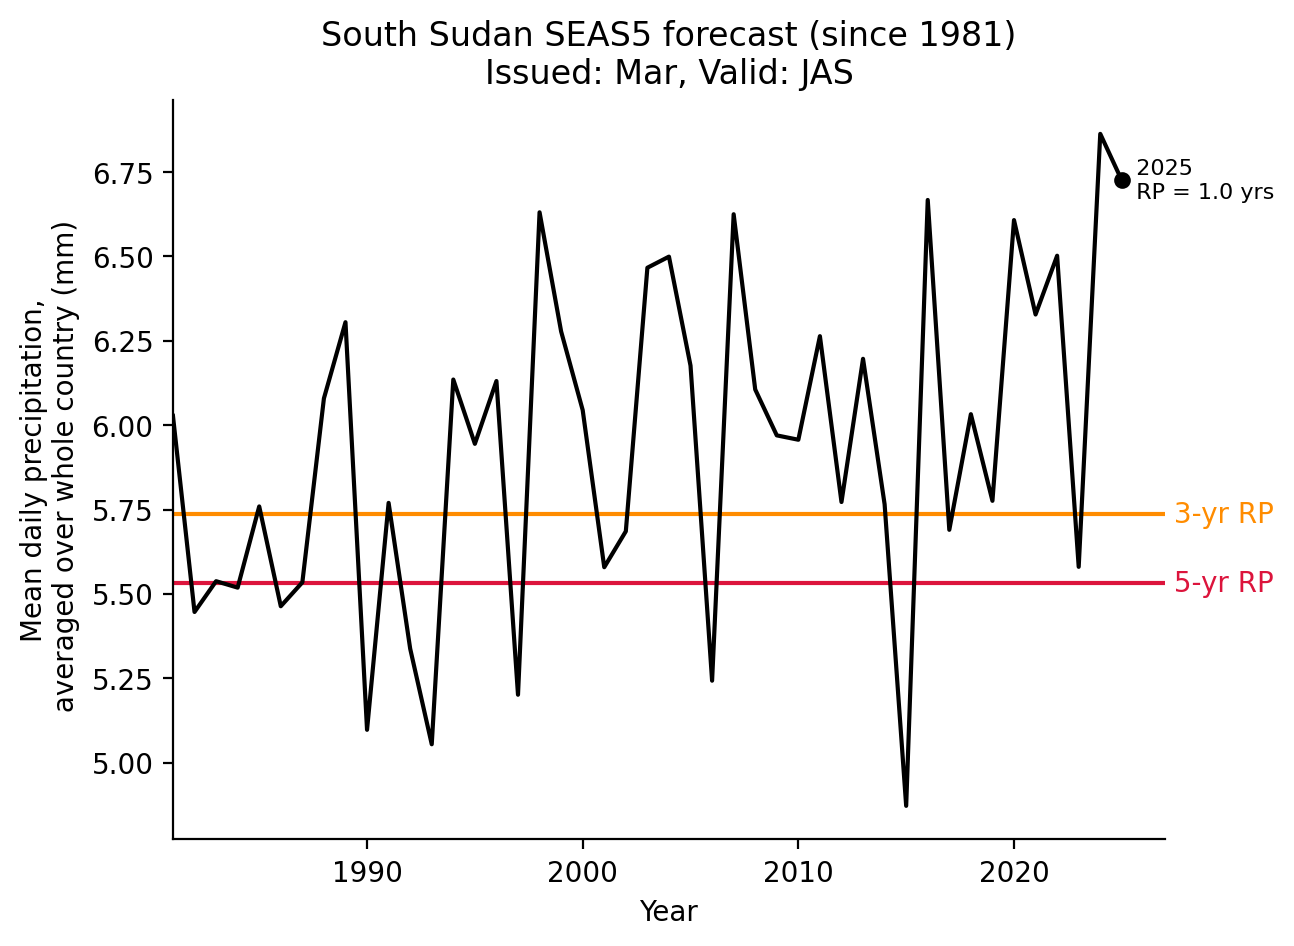

In [25]:
issued_month = 3
valid_months = [7, 8, 9]
min_year = 1981

df_jj = (
    df_seas5[
        (df_seas5["valid_date"].dt.month.isin(valid_months))
        & (df_seas5["issued_date"].dt.month == issued_month)
        & (df_seas5["valid_date"].dt.year >= min_year)
    ]
    .groupby("issued_date")["mean"]
    .mean()
    .reset_index()
)
df_jj["year"] = df_jj["issued_date"].dt.year

df_jj = rp_calc.calculate_one_group_rp(df_jj, ascending=True)

issued_month_str = calendar.month_abbr[issued_month]

valid_months_str = "".join([calendar.month_abbr[x][0] for x in valid_months])

fig, ax = plt.subplots(dpi=200)

current_row = df_jj[df_jj["issued_date"].dt.year == 2025].iloc[0]

ax.annotate(
    f"  2025\n  RP = {current_row['mean_rp']:.1f} yrs",
    (2025, current_row["mean"]),
    ha="left",
    va="center",
    fontsize=8,
)

for rp, color in zip([3, 5], ["darkorange", "crimson"]):
    thresh = df_jj["mean"].quantile(1 / rp)
    ax.axhline(thresh, color=color)
    ax.annotate(
        f" {rp}-yr RP", (2027, thresh), va="center", ha="left", color=color
    )

df_jj.plot(x="year", y="mean", ax=ax, legend=False, color="k")

ax.plot(
    [2025],
    [current_row["mean"]],
    marker=".",
    color="k",
    markersize=10,
)

ax.set_title(
    f"South Sudan SEAS5 forecast (since {min_year})\n"
    f"Issued: {issued_month_str}, Valid: {valid_months_str}"
)
ax.set_xlabel("Year")
ax.set_ylabel("Mean daily precipitation,\n averaged over whole country (mm)")

ax.set_xlim(left=min_year, right=2027)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)